In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load processed dataset
df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\data\processed\zomato_with_refunds.csv')

# Recreate customer stats
customer_stats = df.groupby('Customer_ID').agg(
    Total_Orders=('ID', 'count'),
    Total_Refunds=('Refund_Requested', 'sum'),
    Total_Refund_Amount=('Refund_Amount', 'sum')
).reset_index()

customer_stats['Refund_Rate'] = (
    customer_stats['Total_Refunds'] / 
    customer_stats['Total_Orders'] * 100
).round(2)

# Apply minimum order threshold
high_risk = customer_stats[
    (customer_stats['Total_Orders'] >= 5) & 
    (customer_stats['Refund_Rate'] > 30)
].copy()

print(f"Dataset loaded: {df.shape}")
print(f"High risk accounts: {len(high_risk)}")

Dataset loaded: (45584, 24)
High risk accounts: 279


In [2]:
# Get refund records only
refund_df = df[df['Refund_Requested'] == True].copy()

# For each customer, find their most repeated refund reason
def get_top_reason_rate(group):
    if len(group) == 0:
        return 0
    reason_counts = group['Refund_Reason'].value_counts()
    top_reason_count = reason_counts.iloc[0]
    return round(top_reason_count / len(group) * 100, 2)

reason_repetition = refund_df.groupby('Customer_ID').apply(
    get_top_reason_rate
).reset_index()
reason_repetition.columns = ['Customer_ID', 'Reason_Repetition_Rate']

# Merge with high risk accounts
high_risk = high_risk.merge(reason_repetition, on='Customer_ID', how='left')
high_risk['Reason_Repetition_Rate'] = high_risk[
    'Reason_Repetition_Rate'
].fillna(0)

print("Reason Repetition Rate added successfully")
print(high_risk[['Customer_ID', 'Total_Refunds', 
                  'Reason_Repetition_Rate']].head(10))

Reason Repetition Rate added successfully
  Customer_ID  Total_Refunds  Reason_Repetition_Rate
0   CUST00026              2                   50.00
1   CUST00063              2                  100.00
2   CUST00070              2                   50.00
3   CUST00144              3                   33.33
4   CUST00155              2                  100.00
5   CUST00212              4                   50.00
6   CUST00244              3                   66.67
7   CUST00260              7                   71.43
8   CUST00278              6                   66.67
9   CUST00330              4                   50.00


In [3]:
# Calculate average complaint length per customer
refund_df['Reason_Length'] = refund_df['Refund_Reason'].str.len()

avg_reason_length = refund_df.groupby('Customer_ID').agg(
    Avg_Reason_Length=('Reason_Length', 'mean')
).reset_index()
avg_reason_length['Avg_Reason_Length'] = avg_reason_length[
    'Avg_Reason_Length'
].round(2)

# Merge with high risk
high_risk = high_risk.merge(avg_reason_length, on='Customer_ID', how='left')

# Overall average for comparison
overall_avg = refund_df['Reason_Length'].mean()
print(f"Overall average reason length: {overall_avg:.2f} characters")
print(f"\nHigh risk customers average reason length:")
print(high_risk['Avg_Reason_Length'].describe())

Overall average reason length: 13.24 characters

High risk customers average reason length:
count    279.000000
mean      13.685197
std        1.721601
min       10.000000
25%       12.330000
50%       13.500000
75%       14.670000
max       17.000000
Name: Avg_Reason_Length, dtype: float64


In [4]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Get refund orders only
refund_df['Order_Date'] = pd.to_datetime(
    refund_df['Order_Date'], dayfirst=True
)

# Calculate days between first and last refund per customer
refund_timeline = refund_df.groupby('Customer_ID').agg(
    First_Refund=('Order_Date', 'min'),
    Last_Refund=('Order_Date', 'max'),
    Total_Refunds=('Refund_Requested', 'count')
).reset_index()

refund_timeline['Days_Span'] = (
    refund_timeline['Last_Refund'] - 
    refund_timeline['First_Refund']
).dt.days

refund_timeline['Refunds_Per_Day'] = (
    refund_timeline['Total_Refunds'] / 
    (refund_timeline['Days_Span'] + 1)
).round(4)

# Merge with high risk
high_risk = high_risk.merge(
    refund_timeline[['Customer_ID', 'Days_Span', 'Refunds_Per_Day']], 
    on='Customer_ID', 
    how='left'
)

print("Refund timeline signal added")
print(high_risk[['Customer_ID', 'Total_Refunds', 
                  'Days_Span', 'Refunds_Per_Day']].head(10))

Refund timeline signal added
  Customer_ID  Total_Refunds  Days_Span  Refunds_Per_Day
0   CUST00026              2         15           0.1250
1   CUST00063              2          2           0.6667
2   CUST00070              2          7           0.2500
3   CUST00144              3          6           0.4286
4   CUST00155              2         15           0.1250
5   CUST00212              4         26           0.1481
6   CUST00244              3         10           0.2727
7   CUST00260              7         45           0.1522
8   CUST00278              6         29           0.2000
9   CUST00330              4         24           0.1600


In [5]:
# Normalize each signal to 0-100 scale
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))

# Signals to combine
signals = ['Refund_Rate', 'Reason_Repetition_Rate', 
           'Refunds_Per_Day', 'Avg_Reason_Length']

# Fill any nulls
high_risk[signals] = high_risk[signals].fillna(0)

# Scale signals
scaled = scaler.fit_transform(high_risk[signals])
scaled_df = pd.DataFrame(scaled, columns=[
    'Score_RefundRate', 'Score_ReasonRepetition',
    'Score_Frequency', 'Score_ReasonLength'
])

# Weighted final score
# Refund Rate and Reason Repetition weighted higher
scaled_df['Fraud_Risk_Score'] = (
    scaled_df['Score_RefundRate'] * 0.40 +
    scaled_df['Score_ReasonRepetition'] * 0.30 +
    scaled_df['Score_Frequency'] * 0.20 +
    scaled_df['Score_ReasonLength'] * 0.10
).round(2)

# Add score to high risk dataframe
high_risk = high_risk.reset_index(drop=True)
high_risk['Fraud_Risk_Score'] = scaled_df['Fraud_Risk_Score']

# Sort by score
final_suspects = high_risk.sort_values(
    'Fraud_Risk_Score', ascending=False
).reset_index(drop=True)

print("Top 15 Fraud Suspects:")
print(final_suspects[[
    'Customer_ID', 'Total_Orders', 'Total_Refunds',
    'Refund_Rate', 'Reason_Repetition_Rate',
    'Fraud_Risk_Score', 'Total_Refund_Amount'
]].head(15))

Top 15 Fraud Suspects:
   Customer_ID  Total_Orders  Total_Refunds  Refund_Rate  \
0    CUST07704             5              5       100.00   
1    CUST05625             5              5       100.00   
2    CUST04308             5              5       100.00   
3    CUST00790             7              6        85.71   
4    CUST05675             6              6       100.00   
5    CUST07852             6              5        83.33   
6    CUST07954             5              5       100.00   
7    CUST09899             5              5       100.00   
8    CUST03483             5              4        80.00   
9    CUST08584             7              7       100.00   
10   CUST06173             8              7        87.50   
11   CUST05191             8              6        75.00   
12   CUST04329             6              6       100.00   
13   CUST09715             6              6       100.00   
14   CUST07044             5              5       100.00   

    Reason_Repet

Fraud suspects saved: 279 accounts


C:\Users\user\AppData\Local\Temp\ipykernel_7172\4166724354.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x='Fraud_Risk_Score',


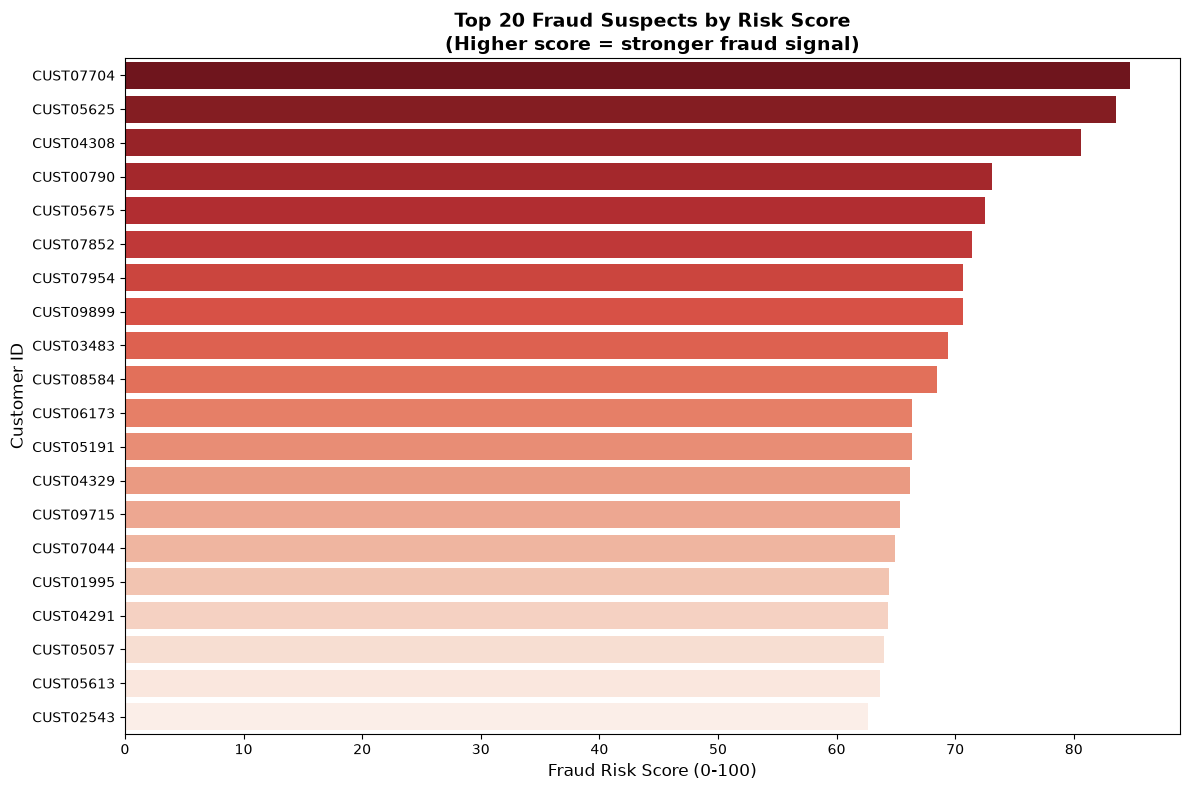

Chart saved!


In [6]:
# Save fraud suspects list
output_path = r'C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\reports\fraud_suspects.csv'
final_suspects.to_csv(output_path, index=False)
print(f"Fraud suspects saved: {len(final_suspects)} accounts")

# Visualize top 20 by fraud score
screenshots_path = r'C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\dashboard\screenshots'

plt.figure(figsize=(12, 8))
top20 = final_suspects.head(20)
sns.barplot(data=top20, x='Fraud_Risk_Score', 
            y='Customer_ID', palette='Reds_r')
plt.title('Top 20 Fraud Suspects by Risk Score\n(Higher score = stronger fraud signal)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fraud Risk Score (0-100)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.tight_layout()
plt.savefig(f'{screenshots_path}\\fraud_suspects_ranking.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")